# Data Analyst - Agriculture Health AI Project

This notebook contains the Data Analyst work for the Agriculture Health AI Project.

This version reads the actual CSV result files from the Data Scientist folder, so the analysis stays synced with the group project.

Main analysis:

- Dataset class distribution
- Dataset split distribution
- Training and validation accuracy/loss for each model
- Final model comparison
- Hyperparameter tuning results
- Confusion matrix evaluation
- Final conclusion

## 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Current notebook location should be:
# Agriculture_Health_AI_Project/Data_Analyst/notebooks/

base_dir = Path.cwd()

# Try to find the main project folder automatically
if base_dir.name == "notebooks":
    project_dir = base_dir.parent.parent
else:
    project_dir = base_dir

data_scientist_results = project_dir / "Data_Scientist" / "results"
output_dir = project_dir / "Data_Analyst" / "visualizations"
output_dir.mkdir(parents=True, exist_ok=True)

print("Current folder:", base_dir)
print("Project folder:", project_dir)
print("Data Scientist results folder:", data_scientist_results)
print("Output folder:", output_dir)

Current folder: C:\Users\User\Documents\Agriculture_Health_AI_Project\Data_Analyst\notebooks
Project folder: C:\Users\User\Documents\Agriculture_Health_AI_Project
Data Scientist results folder: C:\Users\User\Documents\Agriculture_Health_AI_Project\Data_Scientist\results
Output folder: C:\Users\User\Documents\Agriculture_Health_AI_Project\Data_Analyst\visualizations


## 2. Check Required Files

This section checks whether the required Data Scientist result files are available.

In [2]:
required_files = [
    "final_model_comparison.csv",
    "resnet50_history.csv",
    "densenet121_history.csv",
    "mobilenetv3small_history.csv",
    "selected_hyperparameters.csv",
    "hyperparameter_tuning_results.csv"
]

for file_name in required_files:
    file_path = data_scientist_results / file_name
    print(file_name, "FOUND" if file_path.exists() else "MISSING")

final_model_comparison.csv FOUND
resnet50_history.csv FOUND
densenet121_history.csv FOUND
mobilenetv3small_history.csv FOUND
selected_hyperparameters.csv FOUND
hyperparameter_tuning_results.csv FOUND


## 3. Dataset Overview

The dataset contains 5 plant disease classes. Each class contains 1,150 images, giving a total of 5,750 images.

In [3]:
class_data = {
    "Class": [
        "yellow_leaf_disease",
        "leaf_rust",
        "powdery_mildew",
        "leaf_spot",
        "leaf_blight"
    ],
    "Train": [812, 812, 812, 812, 812],
    "Validation": [164, 164, 164, 164, 164],
    "Test": [174, 174, 174, 174, 174]
}

dataset_df = pd.DataFrame(class_data)
dataset_df["Total"] = dataset_df["Train"] + dataset_df["Validation"] + dataset_df["Test"]
dataset_df

,Class,Train,Validation,Test,Total
0,yellow_leaf_disease,812,164,174,1150
1,leaf_rust,812,164,174,1150
2,powdery_mildew,812,164,174,1150
3,leaf_spot,812,164,174,1150
4,leaf_blight,812,164,174,1150


## 4. Class Distribution

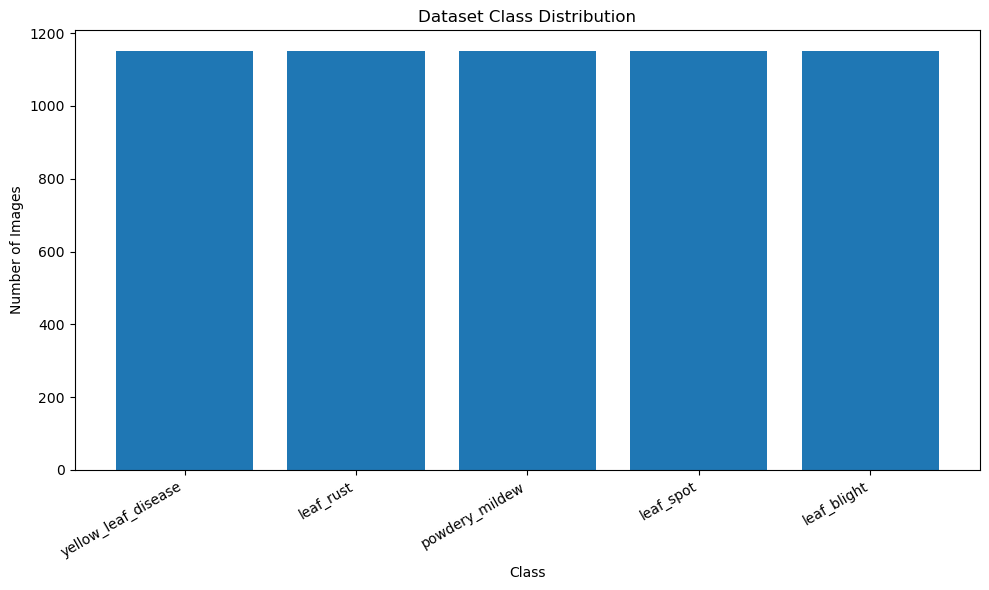

In [4]:
plt.figure(figsize=(10, 6))
plt.bar(dataset_df["Class"], dataset_df["Total"])
plt.title("Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(output_dir / "class_distribution.png", dpi=300)
plt.show()

## 5. Dataset Split Distribution

In [5]:
split_df = pd.DataFrame({
    "Dataset Split": ["Training", "Validation", "Testing"],
    "Number of Images": [
        dataset_df["Train"].sum(),
        dataset_df["Validation"].sum(),
        dataset_df["Test"].sum()
    ]
})

split_df

,Dataset Split,Number of Images
0,Training,4060
1,Validation,820
2,Testing,870


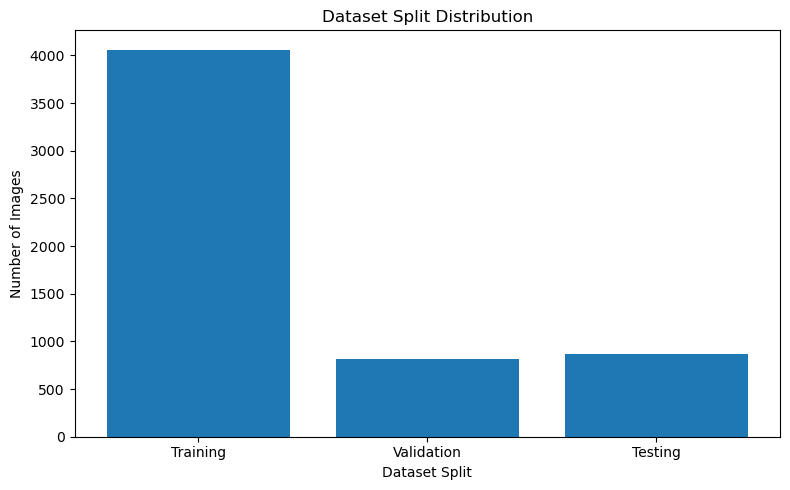

In [6]:
plt.figure(figsize=(8, 5))
plt.bar(split_df["Dataset Split"], split_df["Number of Images"])
plt.title("Dataset Split Distribution")
plt.xlabel("Dataset Split")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.savefig(output_dir / "dataset_split_distribution.png", dpi=300)
plt.show()

## 6. Load Data Scientist Model Results

This section reads the final model comparison CSV from the Data Scientist results folder.

In [7]:
model_df = pd.read_csv(data_scientist_results / "final_model_comparison.csv")
model_df

,Model,Test Accuracy,Test Accuracy (%),Test Loss,mAP,mAP (%),Training Time (seconds),Training Time (minutes),Total Parameters
0,ResNet50,0.711494,71.149427,0.898819,0.785578,78.557766,5880.304603,98.005077,23597957
1,DenseNet121,0.635632,63.563216,0.947757,0.705842,70.584228,5988.468668,99.807811,7042629
2,MobileNetV3Small,0.626437,62.643677,0.978535,0.689870,68.987027,492.150125,8.202502,942005


## 7. Model Accuracy Comparison

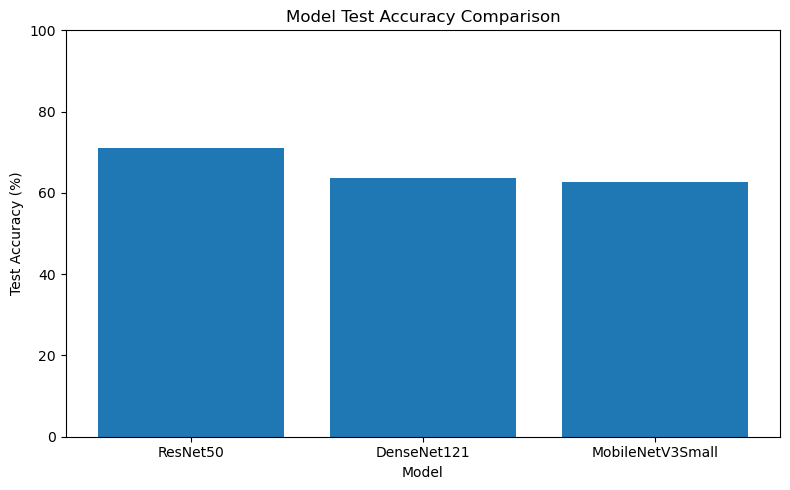

In [8]:
plt.figure(figsize=(8, 5))
plt.bar(model_df["Model"], model_df["Test Accuracy (%)"])
plt.title("Model Test Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig(output_dir / "model_accuracy_comparison.png", dpi=300)
plt.show()

## 8. Model mAP Comparison

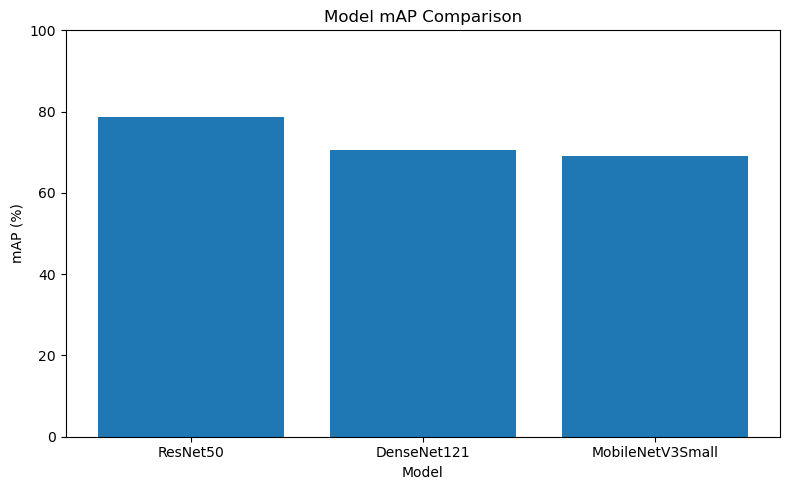

In [9]:
plt.figure(figsize=(8, 5))
plt.bar(model_df["Model"], model_df["mAP (%)"])
plt.title("Model mAP Comparison")
plt.xlabel("Model")
plt.ylabel("mAP (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig(output_dir / "model_map_comparison.png", dpi=300)
plt.show()

## 9. Training Time Comparison

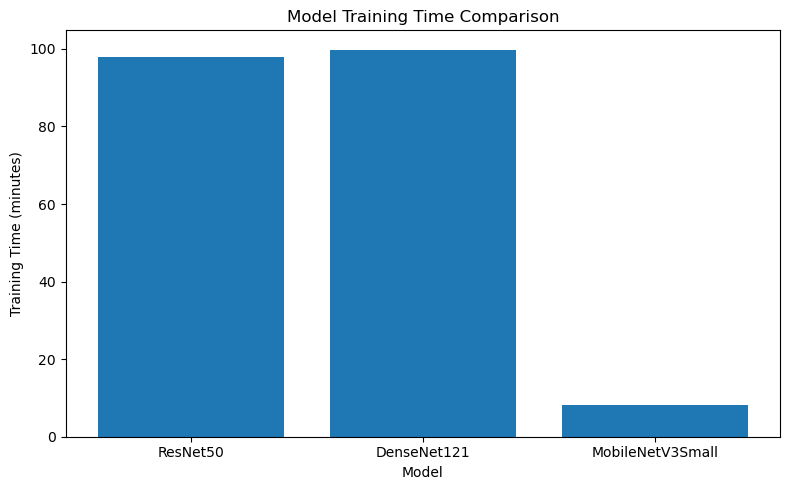

In [10]:
plt.figure(figsize=(8, 5))
plt.bar(model_df["Model"], model_df["Training Time (minutes)"])
plt.title("Model Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Training Time (minutes)")
plt.tight_layout()
plt.savefig(output_dir / "training_time_comparison.png", dpi=300)
plt.show()

## 10. Parameter Comparison

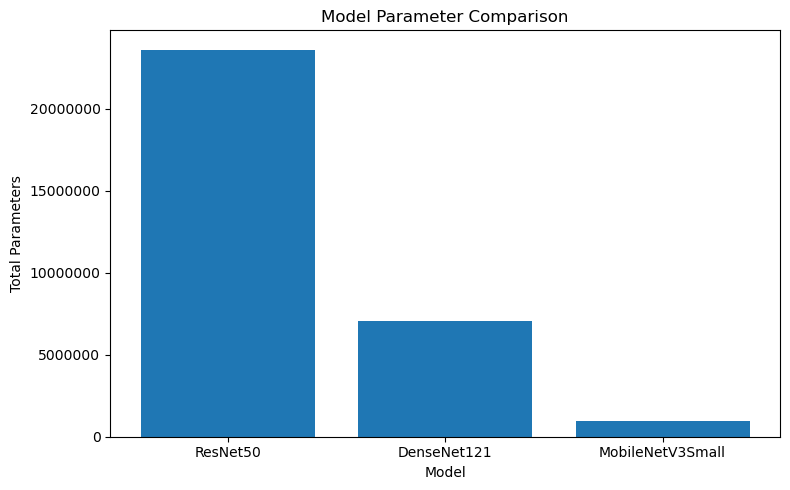

In [11]:
plt.figure(figsize=(8, 5))
plt.bar(model_df["Model"], model_df["Total Parameters"])
plt.title("Model Parameter Comparison")
plt.xlabel("Model")
plt.ylabel("Total Parameters")
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.savefig(output_dir / "parameter_comparison.png", dpi=300)
plt.show()

## 11. Training History: Accuracy and Loss

This section visualizes training and validation accuracy/loss for each model using the history CSV files from the Data Scientist folder.

In [12]:
history_files = {
    "ResNet50": "resnet50_history.csv",
    "DenseNet121": "densenet121_history.csv",
    "MobileNetV3Small": "mobilenetv3small_history.csv"
}

histories = {}

for model_name, file_name in history_files.items():
    histories[model_name] = pd.read_csv(data_scientist_results / file_name)
    histories[model_name]["epoch"] = range(1, len(histories[model_name]) + 1)

for model_name, history_df in histories.items():
    display(history_df.head())

,accuracy,loss,val_accuracy,val_loss,epoch
0,0.437438,1.471544,0.560976,1.165546,1
1,0.597537,1.078844,0.614634,1.048633,2
2,0.641626,0.959448,0.650000,0.964054,3
3,0.666256,0.887577,0.630488,0.983745,4
4,0.683251,0.843545,0.662195,0.958816,5


,accuracy,loss,val_accuracy,val_loss,epoch
0,0.355172,1.618055,0.492683,1.240685,1
1,0.486207,1.285611,0.556098,1.123956,2
2,0.551478,1.148278,0.575610,1.076793,3
3,0.567980,1.115437,0.613415,1.050858,4
4,0.595074,1.076064,0.603659,1.037416,5


,accuracy,loss,val_accuracy,val_loss,epoch
0,0.345074,1.555203,0.520732,1.225070,1
1,0.511330,1.238671,0.576829,1.118432,2
2,0.557389,1.138413,0.586585,1.087971,3
3,0.583990,1.091138,0.595122,1.057883,4
4,0.607882,1.040400,0.596341,1.043645,5


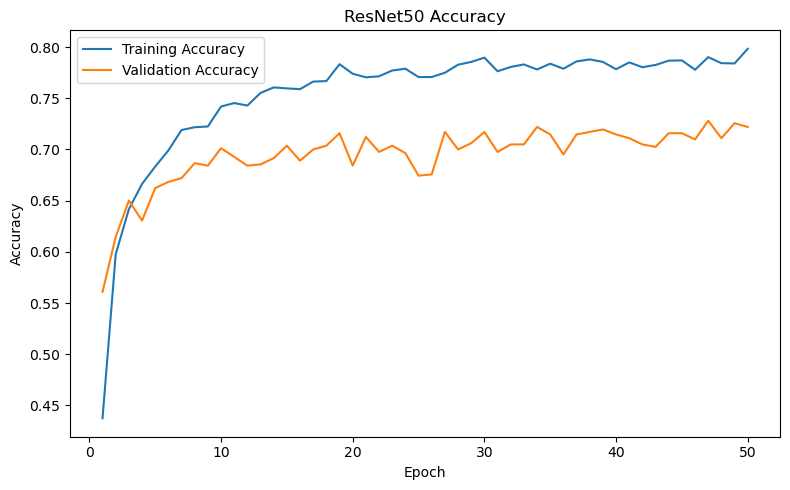

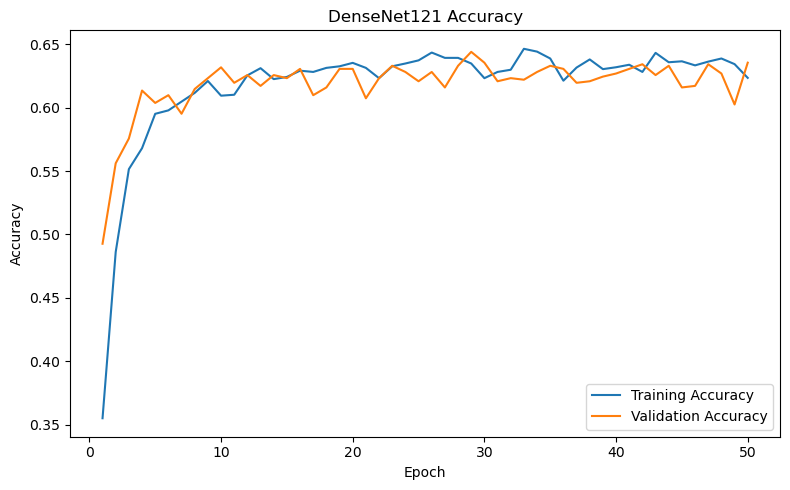

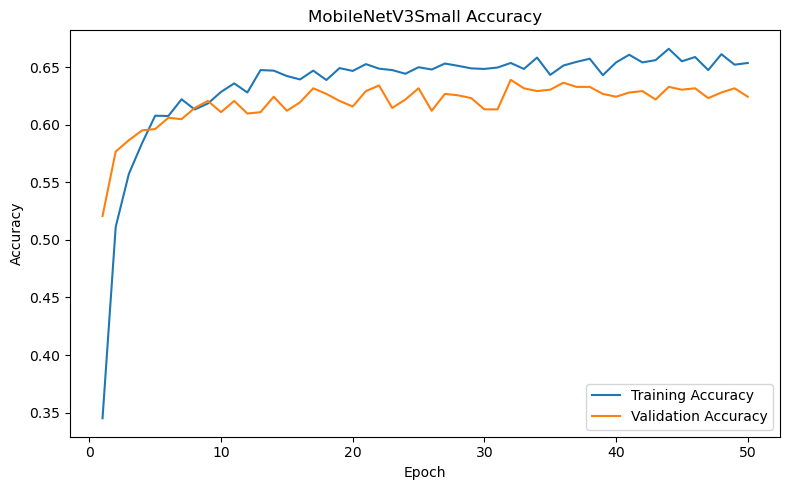

In [13]:
for model_name, history_df in histories.items():
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["accuracy"], label="Training Accuracy")
    plt.plot(history_df["epoch"], history_df["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{model_name} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    file_name = model_name.lower().replace(" ", "_") + "_accuracy.png"
    plt.savefig(output_dir / file_name, dpi=300)
    plt.show()

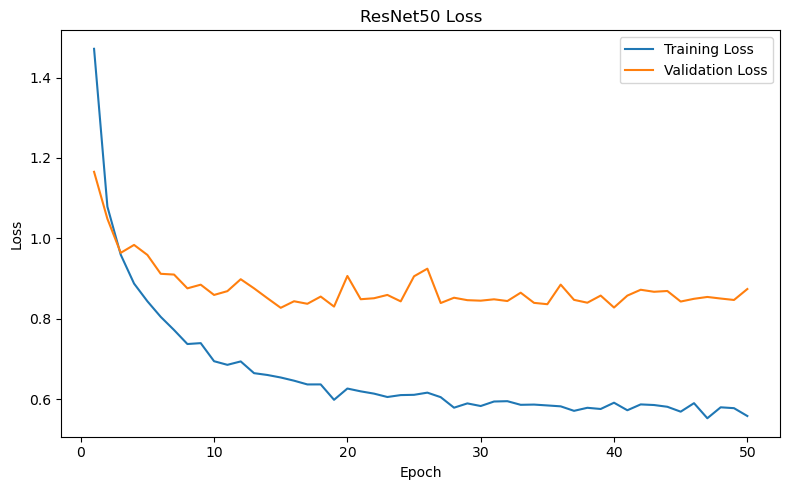

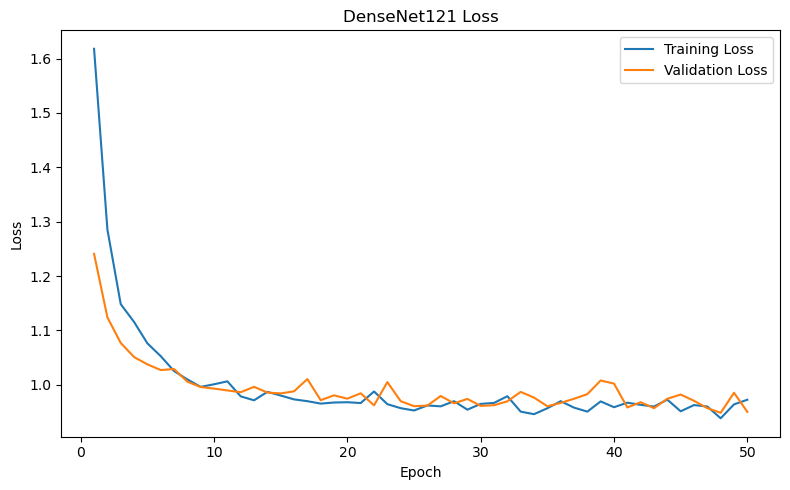

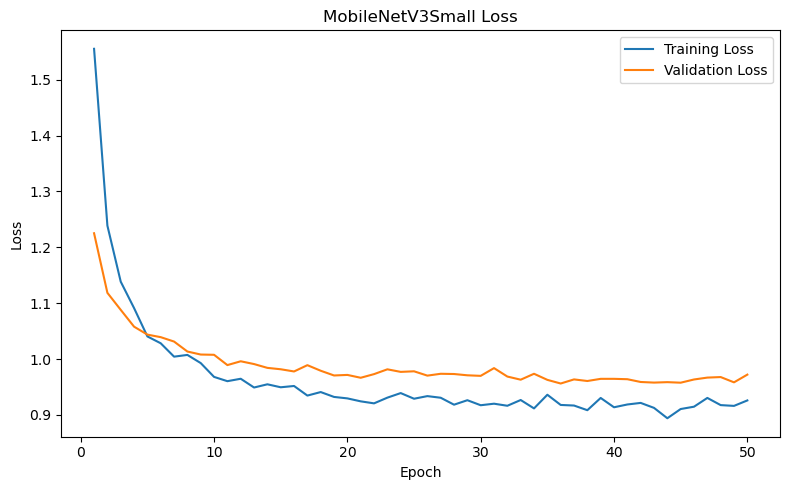

In [14]:
for model_name, history_df in histories.items():
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["loss"], label="Training Loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")
    plt.title(f"{model_name} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    file_name = model_name.lower().replace(" ", "_") + "_loss.png"
    plt.savefig(output_dir / file_name, dpi=300)
    plt.show()

## 12. Hyperparameter Tuning Results

This section uses the new hyperparameter tuning files from the Data Scientist folder.

In [15]:
selected_hyperparameters_df = pd.read_csv(data_scientist_results / "selected_hyperparameters.csv")
selected_hyperparameters_df

,Model,Trial,Learning Rate,Dropout,Trainable Layers,Epochs,Best Validation Accuracy (%),Final Validation Accuracy (%),Training Time (minutes)
0,DenseNet121,Trial 1,0.001,0.3,Frozen base,3,58.41,58.41,6.20
1,MobileNetV3Small,Trial 1,0.001,0.3,Frozen base,3,60.24,60.24,0.54
2,ResNet50,Trial 1,0.001,0.3,Frozen base,3,63.41,63.41,5.84


In [16]:
hyperparameter_tuning_df = pd.read_csv(data_scientist_results / "hyperparameter_tuning_results.csv")
hyperparameter_tuning_df

,Model,Trial,Learning Rate,Dropout,Trainable Layers,Epochs,Best Validation Accuracy,Best Validation Accuracy (%),Final Validation Accuracy,Final Validation Accuracy (%),Final Validation Loss,Training Time (seconds),Training Time (minutes),Total Parameters
0,MobileNetV3Small,Trial 1,0.00100,0.3,Frozen base,3,0.602439,60.24,0.602439,60.24,1.0609,32.626983,0.54,942005
1,MobileNetV3Small,Trial 2,0.00010,0.4,Frozen base,3,0.367073,36.71,0.367073,36.71,1.4710,30.339514,0.51,942005
2,MobileNetV3Small,Trial 3,0.00001,0.3,Fine-tune last 10 layers,3,0.234146,23.41,0.234146,23.41,1.6953,33.746631,0.56,942005
3,ResNet50,Trial 1,0.00100,0.3,Frozen base,3,0.634146,63.41,0.634146,63.41,0.9885,350.440828,5.84,23597957
4,ResNet50,Trial 2,0.00010,0.4,Frozen base,3,0.501220,50.12,0.501220,50.12,1.2536,364.494770,6.07,23597957
5,ResNet50,Trial 3,0.00001,0.3,Fine-tune last 10 layers,3,0.531707,53.17,0.531707,53.17,1.2114,385.284122,6.42,23597957
6,DenseNet121,Trial 1,0.00100,0.3,Frozen base,3,0.584146,58.41,0.584146,58.41,1.0733,371.988369,6.20,7042629
7,DenseNet121,Trial 2,0.00010,0.4,Frozen base,3,0.339024,33.90,0.339024,33.90,1.5101,376.316512,6.27,7042629
8,DenseNet121,Trial 3,0.00001,0.3,Fine-tune last 10 layers,3,0.214634,21.46,0.214634,21.46,1.7155,385.291004,6.42,7042629


## 13. Best Validation Accuracy from Selected Hyperparameters

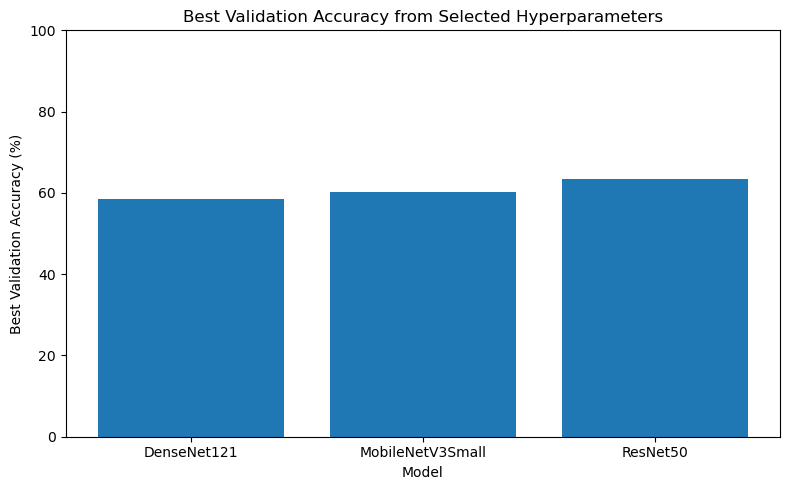

In [17]:
plt.figure(figsize=(8, 5))
plt.bar(selected_hyperparameters_df["Model"], selected_hyperparameters_df["Best Validation Accuracy (%)"])
plt.title("Best Validation Accuracy from Selected Hyperparameters")
plt.xlabel("Model")
plt.ylabel("Best Validation Accuracy (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig(output_dir / "selected_hyperparameters_best_validation_accuracy.png", dpi=300)
plt.show()

## 14. Confusion Matrix

This section visualizes the confusion matrix for each model using the prediction output files from the Data Scientist folder.

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [19]:
prediction_files = {
    "ResNet50": "resnet50_predictions.csv",
    "DenseNet121": "densenet121_predictions.csv",
    "MobileNetV3Small": "mobilenetv3small_predictions.csv"
}

prediction_dfs = {}

for model_name, file_name in prediction_files.items():
    prediction_dfs[model_name] = pd.read_csv(data_scientist_results / file_name)
    display(prediction_dfs[model_name].head())

,Actual Label,Actual Class,Predicted Label,Predicted Class,Probability_leaf_blight,Probability_leaf_rust,Probability_leaf_spot,Probability_powdery_mildew,Probability_yellow_leaf_disease
0,0,leaf_blight,4,yellow_leaf_disease,0.140586,0.039256,0.051495,0.018829,0.749835
1,0,leaf_blight,0,leaf_blight,0.615407,0.024422,0.169286,0.189539,0.001346
2,0,leaf_blight,0,leaf_blight,0.406546,0.012066,0.368779,0.147483,0.065126
3,0,leaf_blight,4,yellow_leaf_disease,0.036761,0.000986,0.105865,0.063782,0.792605
4,0,leaf_blight,0,leaf_blight,0.508215,0.000112,0.124626,0.070984,0.296063


,Actual Label,Actual Class,Predicted Label,Predicted Class,Probability_leaf_blight,Probability_leaf_rust,Probability_leaf_spot,Probability_powdery_mildew,Probability_yellow_leaf_disease
0,0,leaf_blight,4,yellow_leaf_disease,0.103399,0.101453,0.185583,0.004679,0.604886
1,0,leaf_blight,2,leaf_spot,0.430086,0.039069,0.462202,0.007918,0.060725
2,0,leaf_blight,2,leaf_spot,0.233929,0.084198,0.441519,0.049782,0.190572
3,0,leaf_blight,1,leaf_rust,0.089555,0.493040,0.068574,0.009671,0.339160
4,0,leaf_blight,0,leaf_blight,0.854197,0.075092,0.030616,0.007555,0.032541


,Actual Label,Actual Class,Predicted Label,Predicted Class,Probability_leaf_blight,Probability_leaf_rust,Probability_leaf_spot,Probability_powdery_mildew,Probability_yellow_leaf_disease
0,0,leaf_blight,1,leaf_rust,0.028899,0.480905,0.079243,0.003059,0.407895
1,0,leaf_blight,2,leaf_spot,0.123476,0.113733,0.447269,0.107292,0.208230
2,0,leaf_blight,3,powdery_mildew,0.126776,0.066644,0.233455,0.375836,0.197289
3,0,leaf_blight,4,yellow_leaf_disease,0.116149,0.222625,0.215590,0.208434,0.237202
4,0,leaf_blight,3,powdery_mildew,0.325609,0.062219,0.072567,0.361542,0.178063


<Figure size 800x600 with 0 Axes>

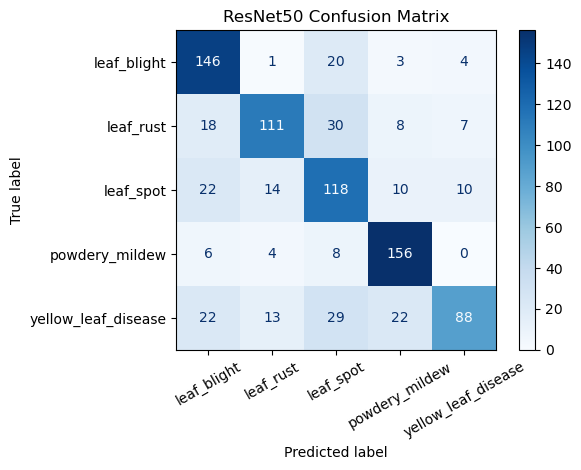

<Figure size 800x600 with 0 Axes>

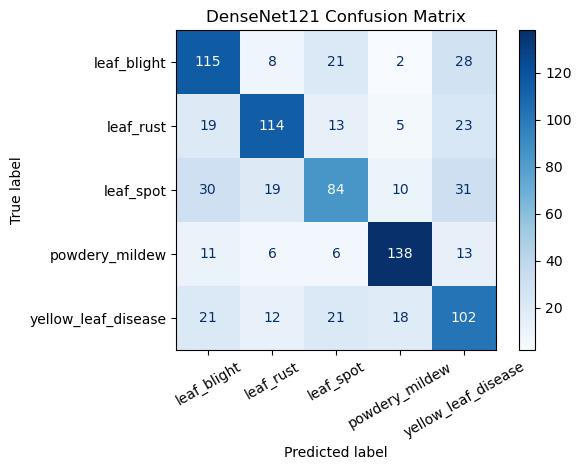

<Figure size 800x600 with 0 Axes>

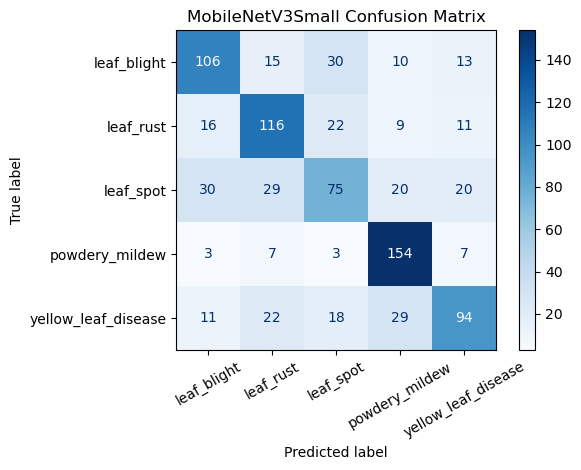

In [20]:
class_labels = [
    "leaf_blight",
    "leaf_rust",
    "leaf_spot",
    "powdery_mildew",
    "yellow_leaf_disease"
]

for model_name, pred_df in prediction_dfs.items():
    cm = confusion_matrix(
        pred_df["Actual Class"],
        pred_df["Predicted Class"],
        labels=class_labels
    )

    plt.figure(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(cmap="Blues", xticks_rotation=30)
    plt.title(f"{model_name} Confusion Matrix")
    plt.tight_layout()

    file_name = model_name.lower().replace(" ", "_") + "_confusion_matrix.png"
    plt.savefig(output_dir / file_name, dpi=300)
    plt.show()

## 15. Confusion Matrix Analysis

The confusion matrix shows how well each model classifies each plant disease class in the testing dataset. The values on the main diagonal represent correct predictions, while the values outside the diagonal represent incorrect predictions.

Based on the confusion matrix, ResNet50 shows the strongest overall classification performance because more predictions are concentrated along the main diagonal. This means ResNet50 correctly classified more testing images compared to the other models.

DenseNet121 also produced reasonable classification results, but it had more misclassifications compared to ResNet50. MobileNetV3Small was the fastest and lightest model, but its confusion matrix shows more incorrect predictions, which matches its lower test accuracy and mAP.

Overall, the confusion matrix supports the final evaluation result that ResNet50 is the most suitable model for this Agriculture Health classification task when accuracy is the main priority.

## 16. Summary Analysis

Based on the final model comparison:

- ResNet50 achieved the highest test accuracy.
- ResNet50 also achieved the highest mAP.
- ResNet50 showed the strongest overall classification performance based on the confusion matrix.
- DenseNet121 required almost the same training time as ResNet50 but produced lower accuracy.
- MobileNetV3Small was the fastest model and had the smallest number of parameters.
- MobileNetV3Small is more suitable when speed and lightweight deployment are important.
- ResNet50 is more suitable when accuracy is the main priority.

## 17. Final Conclusion

ResNet50 is the best model for this Agriculture Health classification task because it achieved the highest test accuracy and mAP. The confusion matrix also supports this result because ResNet50 produced stronger classification performance compared to the other models.

However, ResNet50 has the largest number of parameters and requires longer training time. MobileNetV3Small is the fastest and lightest model, but its accuracy and mAP are lower. Therefore, if accuracy is the main priority, ResNet50 is the most suitable model. If speed and lightweight deployment are more important, MobileNetV3Small can be considered.